## 0. Project Overview

### 0.1 Project Definition

This project aims to build a multi–label classification model for chest X‑ray images using the **Grand X-Ray Slam: Division A** dataset. Each image can exhibit multiple thoracic findings (e.g., Atelectasis, Cardiomegaly, Pleural Effusion) or no finding at all, which makes the task inherently multi-label rather than single-label classification.

The input to the model consists of **chest radiographs** acquired in different views (mainly Frontal and Lateral, with AP/PA distinctions for frontal images). For each image, we have both the pixel data and structured metadata (patient ID, study ID, sex, age, view category, view position). The output of the model is a probability (or binary prediction) for each target condition, including a "No Finding" category and several pathologies such as Atelectasis, Cardiomegaly, Consolidation, Edema, Lung Opacity, Pleural Effusion, and others.

The overarching goal is to learn robust visual representations that can detect and differentiate multiple thoracic pathologies from chest X‑rays, while taking into account the clinical context (e.g., frontal vs. lateral view, patient demographics). This type of system can serve as a decision‑support tool for radiologists and clinicians by highlighting suspicious findings and prioritizing studies for review.

**Citation**

Dhanjal, Guntas, Salah Sammari, Fathi Ben Amor, and Mariem Aissa.  
“Grand X-Ray Slam: Division A.” Kaggle, 2025.  
Available at: https://kaggle.com/competitions/grand-xray-slam-division-a

### 0.2 Fundamental Analysis

The dataset is provided as a combination of:
- **A CSV file** (`train1.csv` / `train.csv`) containing one row per image, with columns:
  - `Image_name`: filename of the corresponding image (e.g., `00000001_001_001.jpg`)
  - `Patient_ID`: identifier of the patient
  - `Study`: study/index for that patient (multiple studies per patient are possible)
  - `Sex`, `Age`: basic demographic information
  - `ViewCategory`: high‑level view type (e.g., `Frontal`, `Lateral`)
  - `ViewPosition`: more specific acquisition parameters (e.g., `AP`, `PA`, `Lateral`)
  - A set of **binary label columns** for each target condition:
    - `Atelectasis`, `Cardiomegaly`, `Consolidation`, `Edema`, `Enlarged Cardiomediastinum`,
      `Fracture`, `Lung Lesion`, `Lung Opacity`, `No Finding`, `Pleural Effusion`,
      `Pleural Other`, `Pneumonia`, `Pneumothorax`, `Support Devices`
    - Each label is encoded as `0` or `1`, and multiple labels can be `1` for the same image.

- **An image folder** containing the raw X‑ray images:
  - Cloud location (OneDrive): `chest_xray/train1`
  - Under WSL, this corresponds to: `/mnt/c/Users/sulay/OneDrive/chest_xray/train1`

This structure naturally defines a **supervised multi‑label learning problem**:
- **Inputs**: chest X‑ray images plus optional metadata (sex, age, view information).
- **Targets**: 14+ binary labels indicating the presence or absence of specific radiological findings.
- **Outputs**: for each image, a vector of probabilities or binary predictions for all target conditions.

From a data perspective, we must account for:
- **Multiple images per patient and per study**, potentially including both frontal and lateral views.
- **Class imbalance**, as some conditions are much rarer than others.
- **Correlations between labels** (e.g., cardiomegaly may co‑occur with other cardiopulmonary findings).
- **View differences** (AP vs. PA vs. Lateral), which affect the appearance and scale of anatomical structures.

Model performance will be evaluated using **multi‑label metrics** such as macro F1‑score and Hamming loss, and aligned with the official competition metric used in the Grand X‑Ray Slam: Division A challenge. The ultimate objective is to design a model that generalizes well across patients, views, and pathologies while remaining clinically meaningful and interpretable.

## 1. Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, hamming_loss, f1_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torchvision import transforms
import torchvision.models as models

import os

# === REPRODUCIBILITY ===
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    torch.backends.cudnn.deterministic = True

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


-----

# 2. Data Validation

In [2]:
# === PATHS (OneDrive, accessible from WSL) ===
IMAGE_ROOT = "/mnt/c/Users/sulay/OneDrive/chest_xray/train1"
CSV_PATH = "/mnt/c/Users/sulay/OneDrive/chest_xray/train1.csv"  # or "train.csv" if needed

# Load metadata
df = pd.read_csv(CSV_PATH)

# Build full image paths
df["image_path"] = df["Image_name"].apply(lambda x: os.path.join(IMAGE_ROOT, x))

# Quick sanity checks
display(df.head())
print(f"Number of rows: {len(df)}")
print(f"Unique patients: {df['Patient_ID'].nunique()}")
print(df[["ViewCategory", "ViewPosition"]].value_counts().head())

,Image_name,Patient_ID,Study,Sex,Age,ViewCategory,ViewPosition,Atelectasis,Cardiomegaly,Consolidation,...,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,image_path
0,00000001_001_001.jpg,1,1,Female,68.0,Frontal,AP,0,0,0,...,0,0,0,0,0,0,0,0,1,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...
1,00000009_001_001.jpg,9,1,Male,76.0,Frontal,PA,0,1,0,...,0,0,0,0,0,0,0,0,0,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...
2,00000009_001_002.jpg,9,1,Male,76.0,Lateral,Lateral,0,1,0,...,0,0,0,0,0,0,0,0,0,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...
3,00000011_013_001.jpg,11,13,Female,22.0,Frontal,PA,0,0,0,...,0,0,0,1,0,0,0,0,0,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...
4,00000011_013_002.jpg,11,13,Female,22.0,Lateral,Lateral,0,0,0,...,0,0,0,1,0,0,0,0,0,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...


Number of rows: 107374
Unique patients: 32076
ViewCategory  ViewPosition
Frontal       AP              60660
              PA              32887
Lateral       Lateral         12315
              LL               1508
Frontal       LL                  4
Name: count, dtype: int64


In [3]:
df.tail()

,Image_name,Patient_ID,Study,Sex,Age,ViewCategory,ViewPosition,Atelectasis,Cardiomegaly,Consolidation,...,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,image_path
107369,20030792_001_000.jpg,20030792,1,Female,9.0,Frontal,PA,0,0,0,...,0,0,0,1,0,0,0,0,0,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...
107370,20030795_000_000.jpg,20030795,0,Female,52.0,Frontal,PA,0,0,0,...,0,0,0,0,0,1,0,0,0,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...
107371,20030798_000_000.jpg,20030798,0,Male,29.0,Frontal,PA,0,0,0,...,0,0,0,1,0,0,0,0,0,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...
107372,20030800_000_000.jpg,20030800,0,Female,33.0,Frontal,PA,0,0,0,...,0,0,0,1,0,0,0,0,0,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...
107373,20030802_000_000.jpg,20030802,0,Male,28.0,Frontal,PA,0,0,0,...,0,0,0,1,0,0,0,0,0,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...


In [14]:
for column_name in df.iloc[:, 7:-2].columns:
    print(f"In {column_name}, the values are: {df[column_name].unique()}")

In Atelectasis, the values are: [0 1]
In Cardiomegaly, the values are: [0 1]
In Consolidation, the values are: [0 1]
In Edema, the values are: [0 1]
In Enlarged Cardiomediastinum, the values are: [0 1]
In Fracture, the values are: [0 1]
In Lung Lesion, the values are: [0 1]
In Lung Opacity, the values are: [0 1]
In No Finding, the values are: [0 1]
In Pleural Effusion, the values are: [0 1]
In Pleural Other, the values are: [0 1]
In Pneumonia, the values are: [0 1]
In Pneumothorax, the values are: [0 1]
In Support Devices, the values are: [1 0]


In [4]:
df["image_exists"] = df["image_path"].apply(lambda p: 1 if os.path.exists(p) else 0)

df.head()

,Image_name,Patient_ID,Study,Sex,Age,ViewCategory,ViewPosition,Atelectasis,Cardiomegaly,Consolidation,...,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,image_path,image_exists
0,00000001_001_001.jpg,1,1,Female,68.0,Frontal,AP,0,0,0,...,0,0,0,0,0,0,0,1,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...,1
1,00000009_001_001.jpg,9,1,Male,76.0,Frontal,PA,0,1,0,...,0,0,0,0,0,0,0,0,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...,1
2,00000009_001_002.jpg,9,1,Male,76.0,Lateral,Lateral,0,1,0,...,0,0,0,0,0,0,0,0,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...,1
3,00000011_013_001.jpg,11,13,Female,22.0,Frontal,PA,0,0,0,...,0,0,1,0,0,0,0,0,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...,1
4,00000011_013_002.jpg,11,13,Female,22.0,Lateral,Lateral,0,0,0,...,0,0,1,0,0,0,0,0,/mnt/c/Users/sulay/OneDrive/chest_xray/train1/...,1


In [5]:
df["image_exists"].value_counts()

image_exists
1    107308
0        66
Name: count, dtype: int64

In [7]:
df.isna().sum()

Image_name                        0
Patient_ID                        0
Study                             0
Sex                           14766
Age                           14766
ViewCategory                      0
ViewPosition                      0
Atelectasis                       0
Cardiomegaly                      0
Consolidation                     0
Edema                             0
Enlarged Cardiomediastinum        0
Fracture                          0
Lung Lesion                       0
Lung Opacity                      0
No Finding                        0
Pleural Effusion                  0
Pleural Other                     0
Pneumonia                         0
Pneumothorax                      0
Support Devices                   0
image_path                        0
image_exists                      0
dtype: int64

<Axes: >

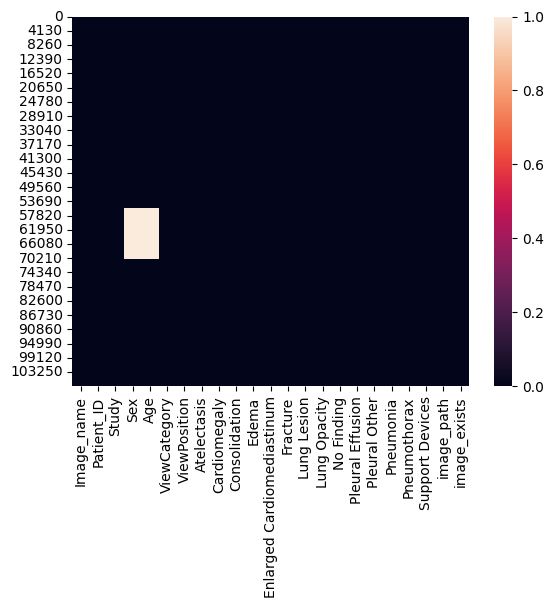

In [6]:
sns.heatmap(df.isna())

### Summary

The training metadata was loaded from the CSV and linked to the image folder via full paths. We verified that (1) image–CSV alignment: each row has a unique Image_name and we added an image_exists flag (1 if the file is present on disk, 0 otherwise) so that rows with missing images can be filtered or inspected later; (2) missing values: only Sex and Age contain missing values (14,766 rows); since the model uses only the scan as input, no imputation or row removal was applied for training; (3) labels: all 14 pathology columns are binary (0/1) with no missing values; (4) identifiers and views: Patient_ID, Study, ViewCategory, and ViewPosition are complete and consistent. No further data cleaning was required for the image-based multi-label pipeline.

--------

## 3. Train / Val / Test Split

We filter to rows where the image exists on disk, then split into train (80%), validation (10%), and test (10%) using **multilabel stratified sampling** so that label distributions are preserved in each split. EDA and model training will use the **training set only**.

In [22]:
LABEL_COLS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Enlarged Cardiomediastinum", "Fracture", "Lung Lesion", "Lung Opacity",
    "No Finding", "Pleural Effusion", "Pleural Other", "Pneumonia",
    "Pneumothorax", "Support Devices"
]

# Keep only rows with existing images
df_work = df[df["image_exists"] == 1].copy()

# First split: 90% train+val, 10% test
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
trainval_idx, test_idx = next(msss.split(df_work[LABEL_COLS], df_work[LABEL_COLS]))
df_trainval = df_work.iloc[trainval_idx].reset_index(drop=True)
df_test = df_work.iloc[test_idx].reset_index(drop=True)

# Second split: ~89% train, ~11% val (so overall ~80% train, ~10% val, ~10% test)
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.111, random_state=SEED)
train_idx, val_idx = next(msss2.split(df_trainval[LABEL_COLS], df_trainval[LABEL_COLS]))
df_train = df_trainval.iloc[train_idx].reset_index(drop=True)
df_val = df_trainval.iloc[val_idx].reset_index(drop=True)

n = len(df_train)
print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Train: 85828, Val: 10701, Test: 10779


## 4. Exploratory Data Analysis

EDA is performed on the **training set only** (`df_train`) to avoid any look-ahead bias and to describe the data the model will learn from.

In [23]:
df_train.columns

Index(['Image_name', 'Patient_ID', 'Study', 'Sex', 'Age', 'ViewCategory',
       'ViewPosition', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
       'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia',
       'Pneumothorax', 'Support Devices', 'image_path', 'image_exists'],
      dtype='str')

In [24]:
LABEL_COLS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Enlarged Cardiomediastinum", "Fracture", "Lung Lesion", "Lung Opacity",
    "No Finding", "Pleural Effusion", "Pleural Other", "Pneumonia",
    "Pneumothorax", "Support Devices"
]

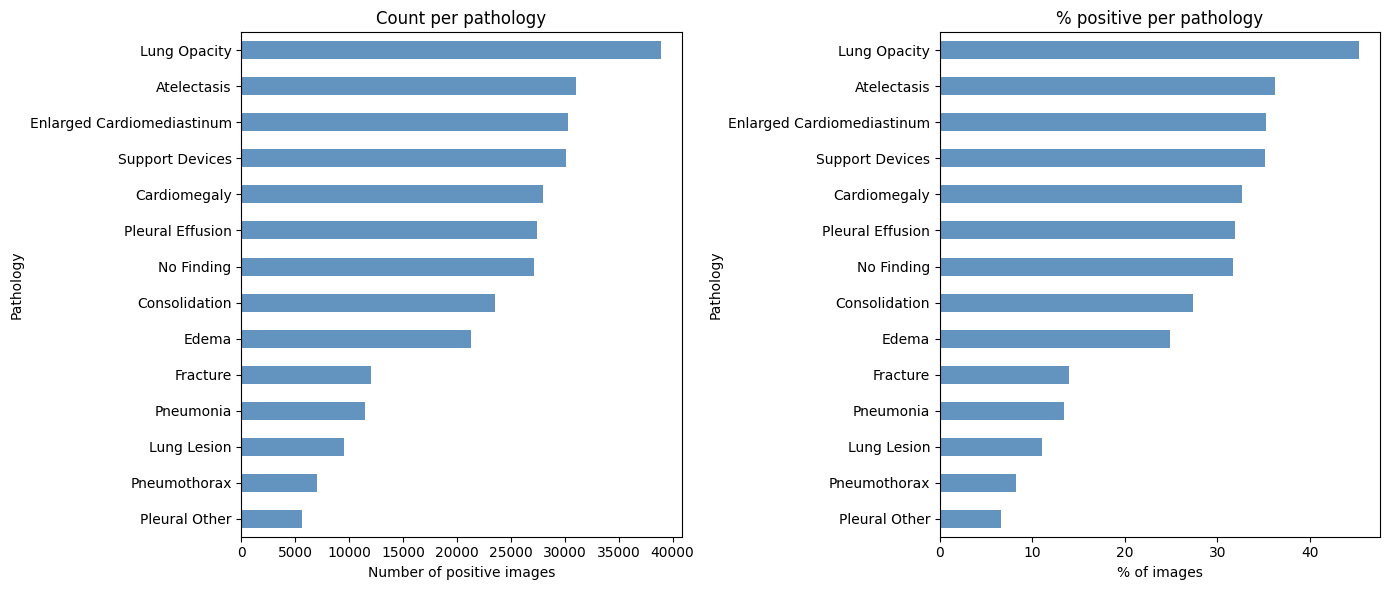

In [25]:
counts = df_train[LABEL_COLS].sum().sort_values(ascending=True)
pct = (counts / n * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
counts.plot(kind="barh", ax=ax1, color="steelblue", alpha=0.85)
ax1.set_xlabel("Number of positive images")
ax1.set_ylabel("Pathology")
ax1.set_title("Count per pathology")

pct.plot(kind="barh", ax=ax2, color="steelblue", alpha=0.85)
ax2.set_xlabel("% of images")
ax2.set_ylabel("Pathology")
ax2.set_title("% positive per pathology")
plt.tight_layout()
plt.show()

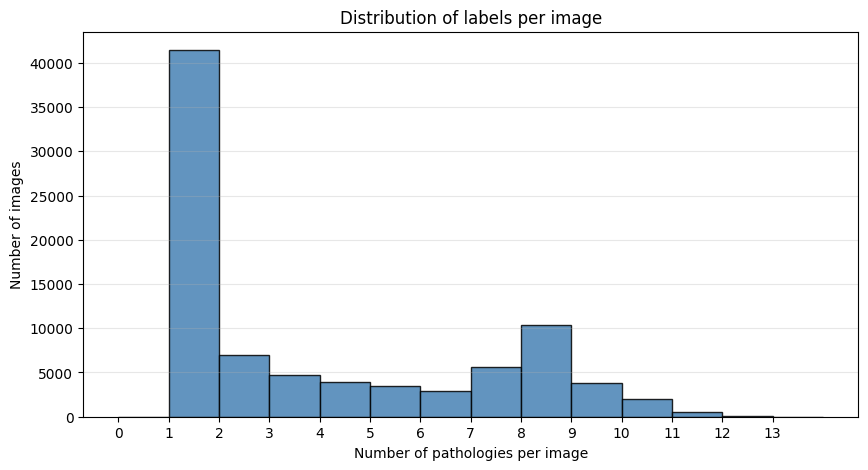

Mean labels per image: 3.53
Median labels per image: 2
Max labels per image: 13


In [26]:
labels_per_image = df_train[LABEL_COLS].sum(axis=1)
plt.figure(figsize=(10, 5))
plt.hist(labels_per_image, bins=range(0, labels_per_image.max() + 2), 
         color="steelblue", alpha=0.85, edgecolor="black")
plt.xlabel("Number of pathologies per image")
plt.ylabel("Number of images")
plt.title("Distribution of labels per image")
plt.xticks(range(0, labels_per_image.max() + 1))
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Mean labels per image: {labels_per_image.mean():.2f}")
print(f"Median labels per image: {labels_per_image.median():.0f}")
print(f"Max labels per image: {labels_per_image.max()}")

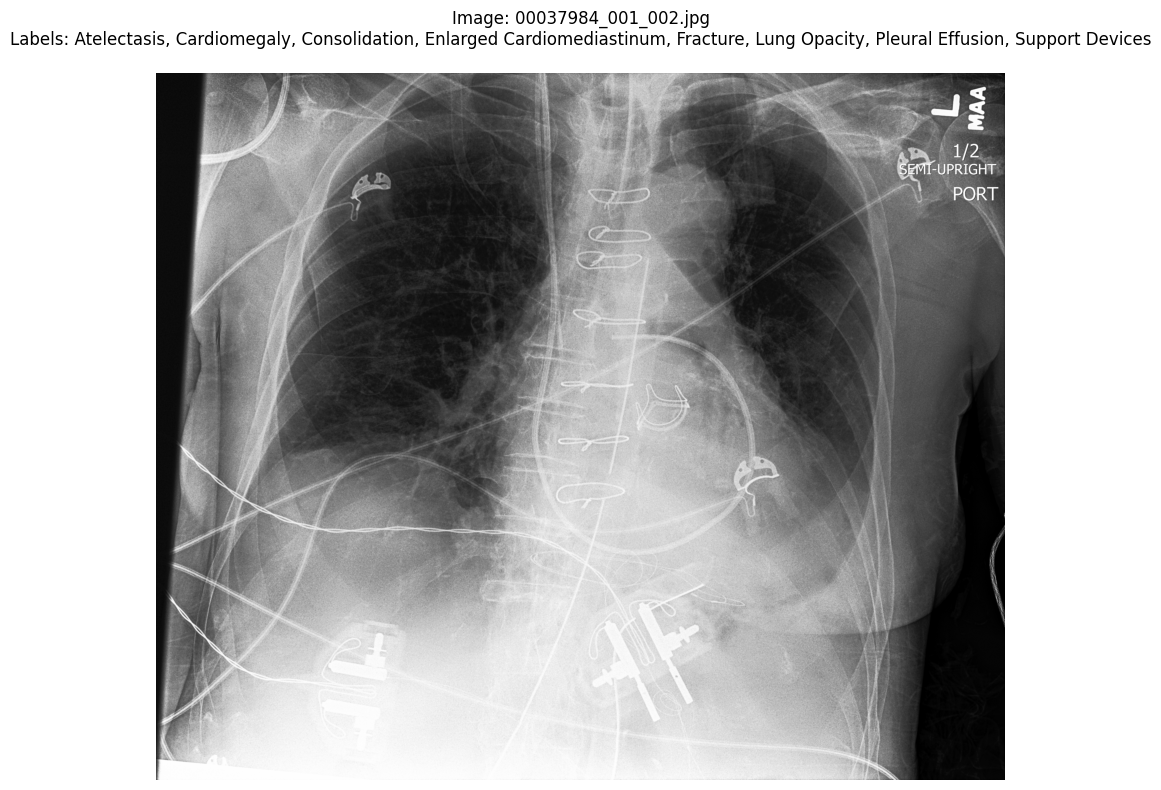

Patient ID: 37984
Age: 67.0
Sex: Female
View: Frontal - AP
Active pathologies: Atelectasis, Cardiomegaly, Consolidation, Enlarged Cardiomediastinum, Fracture, Lung Opacity, Pleural Effusion, Support Devices


In [27]:
# Display a sample image with its labels
sample_idx = df_train[df_train[LABEL_COLS].sum(axis=1) > 0].sample(1).index[0]
sample_row = df_train.loc[sample_idx]

# Get the labels for this image
active_labels = [label for label in LABEL_COLS if sample_row[label] == 1]

# Load and display the image
img = Image.open(sample_row['image_path'])
plt.figure(figsize=(10, 8))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title(f"Image: {sample_row['Image_name']}\nLabels: {', '.join(active_labels) if active_labels else 'No Finding'}", 
          fontsize=12, pad=20)
plt.tight_layout()
plt.show()

print(f"Patient ID: {sample_row['Patient_ID']}")
print(f"Age: {sample_row['Age']}")
print(f"Sex: {sample_row['Sex']}")
print(f"View: {sample_row['ViewCategory']} - {sample_row['ViewPosition']}")
print(f"Active pathologies: {', '.join(active_labels) if active_labels else 'No Finding'}")

## 5. Preprocessing & DataLoaders

Images are loaded from disk, resized to **224 × 224**, and normalised with ImageNet statistics (required by the pretrained backbone). Training images receive light augmentation (random horizontal flip and small rotation) to improve generalisation. Labels are the 14 binary pathology columns extracted directly from the DataFrames.

In [29]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ChestXrayDataset(Dataset):
    """Loads a single chest X-ray from disk and returns (image, labels)."""
    def __init__(self, dataframe, label_cols, transform=None):
        self.paths  = dataframe["image_path"].values
        self.labels = dataframe[label_cols].values.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

BATCH_SIZE = 32
NUM_WORKERS = 2

g = torch.Generator().manual_seed(SEED)

train_dataset = ChestXrayDataset(df_train, LABEL_COLS, transform=train_transforms)
val_dataset   = ChestXrayDataset(df_val,   LABEL_COLS, transform=eval_transforms)
test_dataset  = ChestXrayDataset(df_test,  LABEL_COLS, transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True, generator=g)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_dataset):,} images -> {len(train_loader)} batches")
print(f"Val:   {len(val_dataset):,} images -> {len(val_loader)} batches")
print(f"Test:  {len(test_dataset):,} images -> {len(test_loader)} batches")

Train: 85,828 images -> 2682 batches
Val:   10,701 images -> 335 batches
Test:  10,779 images -> 337 batches


--------

## 6. Model Architecture

We use a **DenseNet-121** backbone pretrained on ImageNet. The original classifier head is replaced by a dropout layer followed by a single linear layer that outputs **14 logits** (one per pathology). This architecture is standard for chest X-ray classification (CheXNet-style).

In [30]:
NUM_CLASSES = len(LABEL_COLS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ChestXrayClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        in_features = backbone.classifier.in_features
        backbone.classifier = nn.Identity()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

model = ChestXrayClassifier().to(device)
total_params   = sum(p.numel() for p in model.parameters())
trainable      = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Device: {device}")

Total parameters:     6,968,206
Trainable parameters: 6,968,206
Device: cuda


--------

## 7. Training

- **Loss**: `BCEWithLogitsLoss` with per-class positive weights computed from training-set prevalence to counteract class imbalance.
- **Optimiser**: AdamW with weight decay.
- **Scheduler**: `ReduceLROnPlateau` monitoring validation loss.
- **Early stopping**: training halts if validation loss does not improve for `PATIENCE` consecutive epochs.
- **Mixed precision** (`torch.amp`) for faster forward/backward passes on GPU.

In [32]:
# ── Positive weights for class imbalance ──
pos_counts = df_train[LABEL_COLS].sum().values
neg_counts = len(df_train) - pos_counts
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-5), dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ── Optimiser & scheduler ──
LR = 1e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 25
PATIENCE = 5

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
use_amp = device.type == "cuda"
scaler = GradScaler() if use_amp else None

print(f"Pos weights (min/max): {pos_weight.min().item():.2f} / {pos_weight.max().item():.2f}")
print(f"LR={LR}, WD={WEIGHT_DECAY}, Epochs={EPOCHS}, Patience={PATIENCE}")

Pos weights (min/max): 1.21 / 14.19
LR=0.0001, WD=1e-05, Epochs=25, Patience=5


In [33]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device, use_amp):
    model.train()
    running_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if use_amp:
            with autocast(device_type="cuda"):
                logits = model(imgs)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        if device.type == "cuda":
            with autocast(device_type="cuda"):
                logits = model(imgs)
                loss = criterion(logits, labels)
        else:
            logits = model(imgs)
            loss = criterion(logits, labels)
        running_loss += loss.item() * imgs.size(0)
        probs = torch.sigmoid(logits)
        all_preds.append((probs >= threshold).cpu().numpy())
        all_targets.append(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    preds   = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)
    f1_mac = f1_score(targets, preds, average="macro", zero_division=0)
    h_loss = hamming_loss(targets, preds)
    return avg_loss, f1_mac, h_loss

In [34]:
CKPT_DIR = "checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

best_val_loss = float("inf")
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_hamming": []}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, use_amp)
    val_loss, val_f1, val_hamming = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    history["val_hamming"].append(val_hamming)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} | "
          f"Val loss: {val_loss:.4f} | "
          f"Val F1-macro: {val_f1:.4f} | "
          f"Val Hamming: {val_hamming:.4f} | "
          f"LR: {lr_now:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join(CKPT_DIR, "best_model.pth"))
        print("  -> Saved best model checkpoint")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Epoch 01/25 | Train loss: 0.6586 | Val loss: 0.5830 | Val F1-macro: 0.6476 | Val Hamming: 0.1937 | LR: 1.00e-04
  -> Saved best model checkpoint
Epoch 02/25 | Train loss: 0.5942 | Val loss: 0.5800 | Val F1-macro: 0.6740 | Val Hamming: 0.1558 | LR: 1.00e-04
  -> Saved best model checkpoint
Epoch 03/25 | Train loss: 0.5688 | Val loss: 0.5642 | Val F1-macro: 0.6754 | Val Hamming: 0.1593 | LR: 1.00e-04
  -> Saved best model checkpoint
Epoch 04/25 | Train loss: 0.5526 | Val loss: 0.5410 | Val F1-macro: 0.6835 | Val Hamming: 0.1565 | LR: 1.00e-04
  -> Saved best model checkpoint
Epoch 05/25 | Train loss: 0.5392 | Val loss: 0.5561 | Val F1-macro: 0.6691 | Val Hamming: 0.1707 | LR: 1.00e-04
Epoch 06/25 | Train loss: 0.5255 | Val loss: 0.5374 | Val F1-macro: 0.6927 | Val Hamming: 0.1465 | LR: 1.00e-04
  -> Saved best model checkpoint
Epoch 07/25 | Train loss: 0.5147 | Val loss: 0.5356 | Val F1-macro: 0.6843 | Val Hamming: 0.1567 | LR: 1.00e-04
  -> Saved best model checkpoint
Epoch 08/25 | Trai

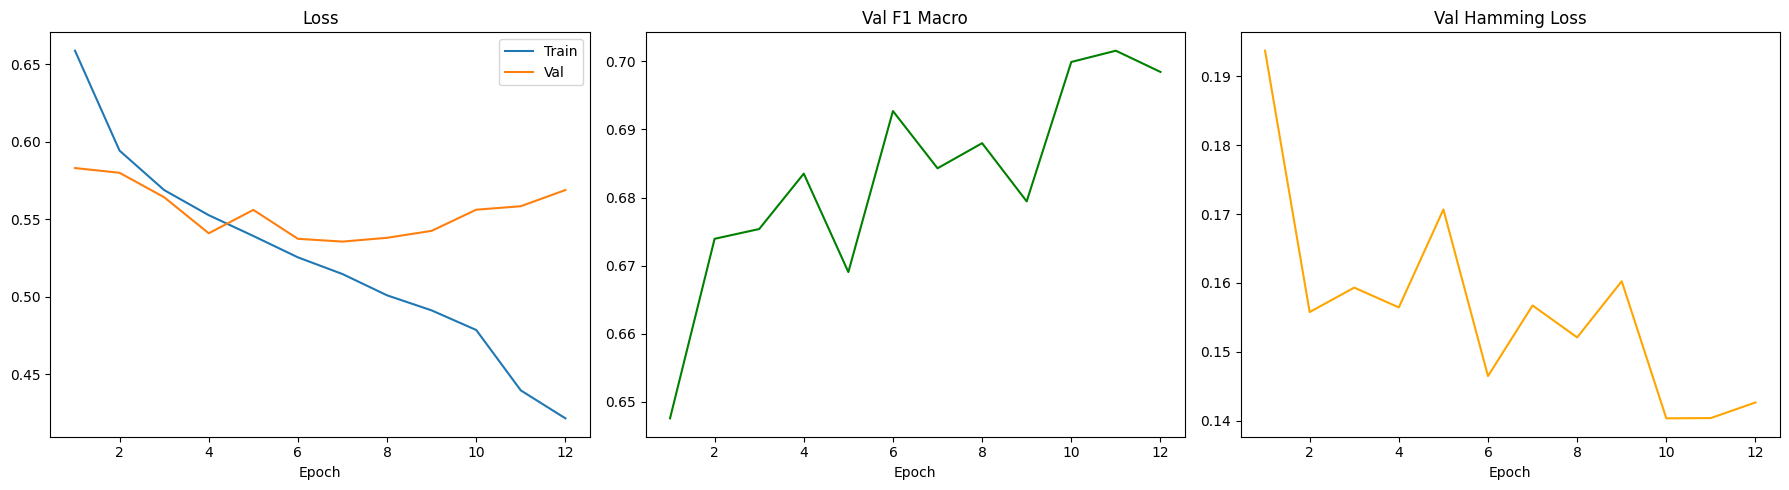

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, history["val_f1"], color="green")
axes[1].set_title("Val F1 Macro"); axes[1].set_xlabel("Epoch")

axes[2].plot(epochs_range, history["val_hamming"], color="orange")
axes[2].set_title("Val Hamming Loss"); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

--------

## 8. Evaluation on Test Set

We reload the best checkpoint and compute final metrics on the **held-out test set** that was never seen during training or hyper-parameter tuning.

In [36]:
model.load_state_dict(torch.load(os.path.join(CKPT_DIR, "best_model.pth"), map_location=device, weights_only=True))
model.eval()

test_loss, test_f1, test_hamming = evaluate(model, test_loader, criterion, device)
print(f"Test loss:    {test_loss:.4f}")
print(f"Test F1-macro: {test_f1:.4f}")
print(f"Test Hamming:  {test_hamming:.4f}")

Test loss:    0.5494
Test F1-macro: 0.6769
Test Hamming:  0.1606


In [37]:
@torch.no_grad()
def get_predictions(model, loader, device, threshold=0.5):
    model.eval()
    all_preds, all_targets = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        if device.type == "cuda":
            with autocast(device_type="cuda"):
                logits = model(imgs)
        else:
            logits = model(imgs)
        probs = torch.sigmoid(logits)
        all_preds.append((probs >= threshold).cpu().numpy())
        all_targets.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_targets)

preds, targets = get_predictions(model, test_loader, device)
print(classification_report(targets, preds, target_names=LABEL_COLS, zero_division=0))

                            precision    recall  f1-score   support

               Atelectasis       0.79      0.78      0.79      3881
              Cardiomegaly       0.75      0.87      0.80      3498
             Consolidation       0.74      0.86      0.80      2937
                     Edema       0.66      0.85      0.74      2665
Enlarged Cardiomediastinum       0.84      0.92      0.88      3784
                  Fracture       0.45      0.85      0.59      1498
               Lung Lesion       0.29      0.74      0.42      1189
              Lung Opacity       0.88      0.76      0.82      4859
                No Finding       0.64      0.90      0.74      3393
          Pleural Effusion       0.71      0.84      0.77      3422
             Pleural Other       0.23      0.77      0.36       706
                 Pneumonia       0.39      0.81      0.53      1437
              Pneumothorax       0.25      0.87      0.39       881
           Support Devices       0.81      0.91

In [38]:
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def get_probabilities(model, loader, device):
    model.eval()
    all_probs, all_targets = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        if device.type == "cuda":
            with autocast(device_type="cuda"):
                logits = model(imgs)
        else:
            logits = model(imgs)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_targets.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_targets)

probs, targets = get_probabilities(model, test_loader, device)

print("Per-class AUC-ROC:")
aucs = []
for i, col in enumerate(LABEL_COLS):
    y = targets[:, i]
    if y.sum() == 0 or y.sum() == len(y):
        print(f"  {col:30s}  — (need both classes)")
        continue
    auc = roc_auc_score(y, probs[:, i])
    aucs.append(auc)
    print(f"  {col:30s}  {auc:.4f}")
print(f"\nMean AUC-ROC: {np.mean(aucs):.4f}" if aucs else "\nNo AUC (all classes constant).")

Per-class AUC-ROC:
  Atelectasis                     0.9129
  Cardiomegaly                    0.9405
  Consolidation                   0.9382
  Edema                           0.9321
  Enlarged Cardiomediastinum      0.9729
  Fracture                        0.9235
  Lung Lesion                     0.8317
  Lung Opacity                    0.9108
  No Finding                      0.9121
  Pleural Effusion                0.9184
  Pleural Other                   0.8775
  Pneumonia                       0.8885
  Pneumothorax                    0.8966
  Support Devices                 0.9627

Mean AUC-ROC: 0.9156
